In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Google Play Store Dataset: Data Cleaning & Feature Engineering 🚀

Hello everyone! In this notebook, we will go through **Data Cleaning** and **Feature Engineering**, which are some of the most crucial and time-consuming stages of any data science project.

The Google Play Store dataset is a great playground for practicing these skills because it contains plenty of hidden errors (e.g., numeric variables disguised as categories, special characters, etc.).

**What will we do in this notebook?**
1. Identify and drop missing values (NaNs).
2. Clean and convert numeric variables that are stuck in string format (`Reviews`, `Size`, `Installs`, `Price`) by stripping special characters.
3. Digitize categorical variables for machine learning models (`Ordinal Encoding` & `Label Encoding`).
4. Visualize the results using a Correlation Heatmap.

Let's get started!

In [2]:
df = pd.read_csv("../07 - Machine Learning/Data/17-googleplaystore.csv")

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  str    
 1   Category        10841 non-null  str    
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  str    
 4   Size            10841 non-null  str    
 5   Installs        10841 non-null  str    
 6   Type            10840 non-null  str    
 7   Price           10841 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10841 non-null  str    
 10  Last Updated    10841 non-null  str    
 11  Current Ver     10833 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(1), str(12)
memory usage: 1.1 MB


## 1. Handling Missing Values 🧹
When we look at the `info()` output, we can see that there are missing values in some columns. To prevent these from misleading our analysis and future machine learning models, we will drop the rows that contain a very small number of missing categorical values.

In [4]:
df.dropna(subset=["Type", "Content Rating", "Current Ver", "Android Ver"], inplace=True) # Na değerler silindi

In [5]:
df

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device


In [6]:
df.info() #reviews int değere dönüşecek, size int değere dönüşecek, installs int değere dönüşecek

<class 'pandas.DataFrame'>
Index: 10829 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10829 non-null  str    
 1   Category        10829 non-null  str    
 2   Rating          9360 non-null   float64
 3   Reviews         10829 non-null  str    
 4   Size            10829 non-null  str    
 5   Installs        10829 non-null  str    
 6   Type            10829 non-null  str    
 7   Price           10829 non-null  str    
 8   Content Rating  10829 non-null  str    
 9   Genres          10829 non-null  str    
 10  Last Updated    10829 non-null  str    
 11  Current Ver     10829 non-null  str    
 12  Android Ver     10829 non-null  str    
dtypes: float64(1), str(12)
memory usage: 1.2 MB


In [7]:
df

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device


In [8]:
df_clean_reviews = df.copy()

## 2. Feature Engineering ⚙️
Machine learning models understand numbers, not text. Therefore, we need to convert columns that represent numerical values but are stored as `object` (string) types in the dataset.

### 2.1. Reviews Column
The `Reviews` column already consists entirely of numbers, but its data type is string. We will directly convert this into an integer format.

In [9]:
df_clean_reviews["Reviews"] = df_clean_reviews["Reviews"].astype(int)

In [10]:
df_clean_reviews.describe() #reviews int değere dönüştü

,Rating,Reviews
count,9360.000000,1.082900e+04
mean,4.191838,4.446018e+05
std,0.515263,2.929213e+06
min,1.000000,0.000000e+00
25%,4.000000,3.800000e+01
50%,4.300000,2.100000e+03
75%,4.500000,5.481500e+04
max,5.000000,7.815831e+07


In [11]:
df_clean_size = df_clean_reviews.copy()

In [12]:
df_clean_size["Size"] # M, Varies with device, k değerleri silenecek

0                       19M
1                       14M
2                      8.7M
3                       25M
4                      2.8M
                ...        
10836                   53M
10837                  3.6M
10838                  9.5M
10839    Varies with device
10840                   19M
Name: Size, Length: 10829, dtype: str

### 2.2. Size Column 📏
The `Size` column contains suffixes like "M" (Megabytes) and "k" (Kilobytes), as well as the text "Varies with device". To standardize this, we will write a function that strips the letters and converts everything to a numeric format (float) consistently in Megabytes.

In [13]:
def clean_size(size):
    if size == "Varies with device":
        return np.nan
    elif "k" in size:
        size = size.replace("k","")
        return float(size)
    elif "M" in size:
        size = size.replace("M","")
        return float(size)
    else:
        return float(size)



In [14]:
df_clean_size["Size"] = df_clean_size["Size"].apply(clean_size)

In [15]:
df_clean_size["Size"] = df_clean_size["Size"].astype(float)

In [16]:
df_clean_size #size değerleri floata çevrildi

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53.0,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,NaN,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device


In [17]:
df_clean_size.describe()

,Rating,Reviews,Size
count,9360.000000,1.082900e+04,9135.000000
mean,4.191838,4.446018e+05,36.947499
std,0.515263,2.929213e+06,98.669772
min,1.000000,0.000000e+00,1.000000
25%,4.000000,3.800000e+01,5.600000
50%,4.300000,2.100000e+03,15.000000
75%,4.500000,5.481500e+04,34.000000
max,5.000000,7.815831e+07,1020.000000


In [18]:
df_clean_install = df_clean_size.copy()

### 2.3. Installs Column 📥
The `Installs` column contains plus (`+`) and comma (`,`) signs (e.g., "10,000+"). We will strip these special characters and convert the data type to an integer to represent the exact download numbers.

In [19]:
def clean_install(install):
    install = install.replace("+", "")
    install = install.replace(",", "")

    return int(install)

def change_variable_install(install):
    return int(install)


In [20]:
df_clean_install["Installs"] = df_clean_install["Installs"].apply(clean_install)

In [21]:
df_clean_install["Installs"] = df_clean_install["Installs"].apply(change_variable_install)

In [22]:
df_clean_install

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,10000,Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,50000000,Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53.0,5000,Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6,100,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5,1000,Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,NaN,1000,Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device


In [23]:
df_clean_install["Type"].unique()

<StringArray>
['Free', 'Paid']
Length: 2, dtype: str

In [24]:
df_clean_install["Price"].info() # price değerlerini floata çeviricez

<class 'pandas.Series'>
Index: 10829 entries, 0 to 10840
Series name: Price
Non-Null Count  Dtype
--------------  -----
10829 non-null  str  
dtypes: str(1)
memory usage: 169.2 KB


In [25]:
df_clean_install["Price"]

0        0
1        0
2        0
3        0
4        0
        ..
10836    0
10837    0
10838    0
10839    0
10840    0
Name: Price, Length: 10829, dtype: str

In [26]:
df_clean_price = df_clean_install.copy()

### 2.4. Price Column 💵
The `Price` column contains dollar signs (`$`) for paid apps. We will remove this sign and convert the column to a float format. Free apps (currently "0") will simply become `0.0`.

In [27]:
def clean_price(price):
    if "$" in price:
        price = price.replace("$","")
        return float(price)
    else:
        return float(price)

In [28]:
df_clean_price["Price"] = df_clean_price["Price"].apply(clean_price)

In [29]:
df_clean_price.describe()

,Rating,Reviews,Size,Installs,Price
count,9360.000000,1.082900e+04,9135.000000,1.082900e+04,10829.000000
mean,4.191838,4.446018e+05,36.947499,1.547990e+07,1.028091
std,0.515263,2.929213e+06,98.669772,8.507114e+07,15.957778
min,1.000000,0.000000e+00,1.000000,0.000000e+00,0.000000
25%,4.000000,3.800000e+01,5.600000,5.000000e+03,0.000000
50%,4.300000,2.100000e+03,15.000000,1.000000e+05,0.000000
75%,4.500000,5.481500e+04,34.000000,5.000000e+06,0.000000
max,5.000000,7.815831e+07,1020.000000,1.000000e+09,400.000000


In [30]:
df_clean_price

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,10000,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,50000000,Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53.0,5000,Free,0.0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6,100,Free,0.0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5,1000,Free,0.0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,NaN,1000,Free,0.0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device


## 3. Categorical Encoding 🧮
To make our categorical variables readable for machine learning algorithms, we need to encode them into numbers.

### 3.1. Ordinal Encoding for Content Rating
Since `Content Rating` (Everyone, Teen, Mature 17+, etc.) has an inherent age-based hierarchy, we will define an order and use **Ordinal Encoding** to assign them ordered numerical values.

In [32]:
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

In [33]:
df_ordinal_rating = df_clean_price.copy()

In [34]:
df_ordinal_rating["Content Rating"].unique()

<StringArray>
['Everyone', 'Teen', 'Everyone 10+', 'Mature 17+', 'Adults only 18+',
 'Unrated']
Length: 6, dtype: str

In [35]:
orth_class_order = ['Everyone', 'Teen', 'Everyone 10+', 'Mature 17+', 'Adults only 18+',
 'Unrated']

In [36]:
ordinal_encoder = OrdinalEncoder(categories=[orth_class_order])

df_ordinal_rating["New Content Rating"] = ordinal_encoder.fit_transform(df_ordinal_rating[["Content Rating"]])

In [37]:
df_ordinal_rating

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,New Content Rating
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,10000,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up,0.0
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,0.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up,0.0
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,50000000,Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up,1.0
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53.0,5000,Free,0.0,Everyone,Education,"July 25, 2017",1.48,4.1 and up,0.0
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6,100,Free,0.0,Everyone,Education,"July 6, 2018",1.0,4.1 and up,0.0
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5,1000,Free,0.0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up,0.0
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,NaN,1000,Free,0.0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device,3.0


In [38]:
df_ordinal_rating[["Content Rating", "New Content Rating"]]

,Content Rating,New Content Rating
0,Everyone,0.0
1,Everyone,0.0
2,Everyone,0.0
3,Teen,1.0
4,Everyone,0.0
...,...,...
10836,Everyone,0.0
10837,Everyone,0.0
10838,Everyone,0.0
10839,Mature 17+,3.0


In [39]:
df_ordinal_rating["Genres"].unique()

<StringArray>
[                   'Art & Design',       'Art & Design;Pretend Play',
         'Art & Design;Creativity', 'Art & Design;Action & Adventure',
                 'Auto & Vehicles',                          'Beauty',
               'Books & Reference',                        'Business',
                          'Comics',               'Comics;Creativity',
 ...
             'Lifestyle;Education',    'Books & Reference;Creativity',
     'Books & Reference;Education',                'Puzzle;Education',
          'Role Playing;Education',        'Role Playing;Brain Games',
              'Strategy;Education',             'Racing;Pretend Play',
        'Communication;Creativity',             'Strategy;Creativity']
Length: 119, dtype: str

In [40]:
df_ordinal_rating["Type"].unique()

<StringArray>
['Free', 'Paid']
Length: 2, dtype: str

### 3.2. Label Encoding for Type
The `Type` column mainly consists of 'Free' and 'Paid' categories. We will use **Label Encoding** to transform these into binary values (0 and 1).

In [41]:
df_clean_type = df_ordinal_rating.copy()

In [42]:
label_encoder = LabelEncoder()

In [43]:
df_clean_type["New Type"] = label_encoder.fit_transform(df_clean_type["Type"])

In [44]:
df_clean_type

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,New Content Rating,New Type
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,10000,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up,0.0,0
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,0.0,0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up,0.0,0
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,50000000,Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up,1.0,0
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53.0,5000,Free,0.0,Everyone,Education,"July 25, 2017",1.48,4.1 and up,0.0,0
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6,100,Free,0.0,Everyone,Education,"July 6, 2018",1.0,4.1 and up,0.0,0
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5,1000,Free,0.0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up,0.0,0
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,NaN,1000,Free,0.0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device,3.0,0


In [45]:
df_clean_type.describe()

,Rating,Reviews,Size,Installs,Price,New Content Rating,New Type
count,9360.000000,1.082900e+04,9135.000000,1.082900e+04,10829.000000,10829.00000,10829.000000
mean,4.191838,4.446018e+05,36.947499,1.547990e+07,1.028091,0.32810,0.073599
std,0.515263,2.929213e+06,98.669772,8.507114e+07,15.957778,0.76176,0.261129
min,1.000000,0.000000e+00,1.000000,0.000000e+00,0.000000,0.00000,0.000000
25%,4.000000,3.800000e+01,5.600000,5.000000e+03,0.000000,0.00000,0.000000
50%,4.300000,2.100000e+03,15.000000,1.000000e+05,0.000000,0.00000,0.000000
75%,4.500000,5.481500e+04,34.000000,5.000000e+06,0.000000,0.00000,0.000000
max,5.000000,7.815831e+07,1020.000000,1.000000e+09,400.000000,5.00000,1.000000


In [46]:
final_df = df_clean_type.copy()

In [47]:
final_df

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,New Content Rating,New Type
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,10000,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up,0.0,0
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,0.0,0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up,0.0,0
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,50000000,Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up,1.0,0
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53.0,5000,Free,0.0,Everyone,Education,"July 25, 2017",1.48,4.1 and up,0.0,0
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6,100,Free,0.0,Everyone,Education,"July 6, 2018",1.0,4.1 and up,0.0,0
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5,1000,Free,0.0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up,0.0,0
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,NaN,1000,Free,0.0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device,3.0,0


## 4. Correlation Heatmap 🗺️
Now that we have successfully cleaned our data and converted our features into numerical formats, let's look at the correlation between all these variables using a Seaborn Heatmap. This will help us understand the relationships between App Ratings, Reviews, Size, Installs, and Price!

<Axes: >

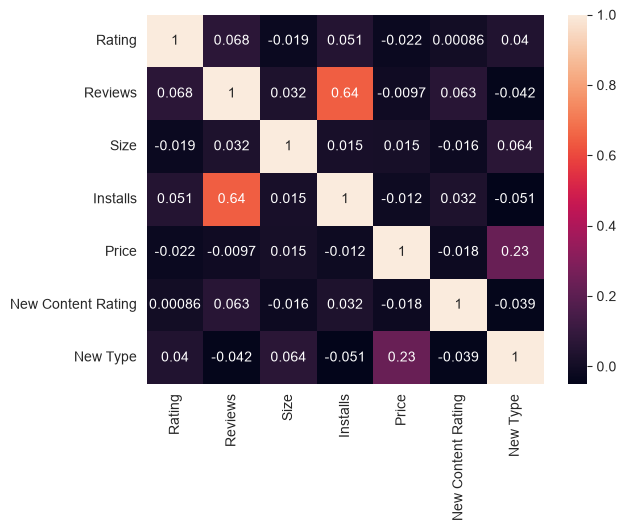

In [48]:
sns.heatmap(final_df.corr(numeric_only=True), annot=True)